In [39]:
# server downtime prediction
import pandas as pd
df = pd.read_csv('Train_data.csv')
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25187,0,tcp,exec,RSTO,0,0,0,0,0,0,...,7,0.03,0.06,0.00,0.00,0.00,0.00,1.00,1.00,anomaly
25188,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,39,1.00,0.00,1.00,0.18,0.00,0.00,0.00,0.00,anomaly
25189,0,tcp,private,REJ,0,0,0,0,0,0,...,13,0.05,0.07,0.00,0.00,0.00,0.00,1.00,1.00,anomaly
25190,0,tcp,nnsp,S0,0,0,0,0,0,0,...,20,0.08,0.06,0.00,0.00,1.00,1.00,0.00,0.00,anomaly


In [40]:
# check whether class column is present in the dataset or not
if 'class' in df.columns:
    print('class column is present in the dataset')
else:
    print('class column is not present in the dataset')

class column is present in the dataset


In [41]:
df.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [42]:
X = [
    'protocol_type',
    'service',
    'flag',
    'src_bytes',
    'dst_bytes',
    'logged_in',
    'count',
    'srv_count',
    'serror_rate',
    'srv_serror_rate',
    'rerror_rate',
    'srv_rerror_rate',
    'same_srv_rate',
    'diff_srv_rate',
    'dst_host_count',
    'dst_host_srv_count',
    'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate',
    'dst_host_serror_rate',
    'dst_host_srv_serror_rate'
]
y =df.columns[-1]
print(y)

class


In [43]:
# keep above columns only in the datset and drop the rest of the columns
df = df[X + [y]]
df

,protocol_type,service,flag,src_bytes,dst_bytes,logged_in,count,srv_count,serror_rate,srv_serror_rate,...,srv_rerror_rate,same_srv_rate,diff_srv_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_serror_rate,dst_host_srv_serror_rate,class
0,tcp,ftp_data,SF,491,0,0,2,2,0.0,0.0,...,0.0,1.00,0.00,150,25,0.17,0.03,0.00,0.00,normal
1,udp,other,SF,146,0,0,13,1,0.0,0.0,...,0.0,0.08,0.15,255,1,0.00,0.60,0.00,0.00,normal
2,tcp,private,S0,0,0,0,123,6,1.0,1.0,...,0.0,0.05,0.07,255,26,0.10,0.05,1.00,1.00,anomaly
3,tcp,http,SF,232,8153,1,5,5,0.2,0.2,...,0.0,1.00,0.00,30,255,1.00,0.00,0.03,0.01,normal
4,tcp,http,SF,199,420,1,30,32,0.0,0.0,...,0.0,1.00,0.00,255,255,1.00,0.00,0.00,0.00,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25187,tcp,exec,RSTO,0,0,0,100,7,0.0,0.0,...,1.0,0.07,0.07,255,7,0.03,0.06,0.00,0.00,anomaly
25188,tcp,ftp_data,SF,334,0,1,1,1,0.0,0.0,...,0.0,1.00,0.00,1,39,1.00,0.00,0.00,0.00,anomaly
25189,tcp,private,REJ,0,0,0,105,7,0.0,0.0,...,1.0,0.07,0.07,255,13,0.05,0.07,0.00,0.00,anomaly
25190,tcp,nnsp,S0,0,0,0,129,18,1.0,1.0,...,0.0,0.14,0.06,255,20,0.08,0.06,1.00,1.00,anomaly


In [44]:
df['class'].value_counts()

class
normal     13449
anomaly    11743
Name: count, dtype: int64

In [45]:
# relpace tne normal with 0 and anomaly with 1 in the class column
df['class'] = df['class'].replace({'normal': 0, 'anomaly': 1})
df['class'].value_counts()

C:\Users\Sree Charan\AppData\Local\Temp\ipykernel_22848\882243116.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['class'] = df['class'].replace({'normal': 0, 'anomaly': 1})
C:\Users\Sree Charan\AppData\Local\Temp\ipykernel_22848\882243116.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['class'] = df['class'].replace({'normal': 0, 'anomaly': 1})


class
0    13449
1    11743
Name: count, dtype: int64

In [46]:
df['service'].value_counts()

service
http         8003
private      4351
domain_u     1820
smtp         1449
ftp_data     1396
             ... 
urh_i           4
red_i           3
pm_dump         3
tim_i           2
http_8001       1
Name: count, Length: 66, dtype: int64

In [47]:
# in serive column there are many unique values so we will keep only top 6 values and replace the rest of the values with other
top_6_services = df['service'].value_counts().nlargest(6).index
df['service'] = df['service'].apply(lambda x: x if x in top_6_services else 'other')
df['service'].value_counts()

C:\Users\Sree Charan\AppData\Local\Temp\ipykernel_22848\823393003.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['service'] = df['service'].apply(lambda x: x if x in top_6_services else 'other')


service
http        8003
other       7264
private     4351
domain_u    1820
smtp        1449
ftp_data    1396
eco_i        909
Name: count, dtype: int64

In [48]:
df['protocol_type'].value_counts()

protocol_type
tcp     20526
udp      3011
icmp     1655
Name: count, dtype: int64

In [49]:
df['flag'].value_counts()

flag
SF        14973
S0         7009
REJ        2216
RSTR        497
RSTO        304
S1           88
SH           43
RSTOS0       21
S2           21
S3           15
OTH           5
Name: count, dtype: int64

In [50]:
# in the flag columns there are many unique values so we will keep only top 5 values and replace the rest of the values with other
top_5_flags = df['flag'].value_counts().nlargest(5).index
df['flag'] = df['flag'].apply(lambda x: x if x in top_5_flags else 'other')
df['flag'].value_counts()

C:\Users\Sree Charan\AppData\Local\Temp\ipykernel_22848\734670376.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['flag'] = df['flag'].apply(lambda x: x if x in top_5_flags else 'other')


flag
SF       14973
S0        7009
REJ       2216
RSTR       497
RSTO       304
other      193
Name: count, dtype: int64

In [52]:
# use label encoder for protocol_type	service	flag	columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['protocol_type'] = le.fit_transform(df['protocol_type'])
df['service'] = le.fit_transform(df['service'])
df['flag'] = le.fit_transform(df['flag'])
df

C:\Users\Sree Charan\AppData\Local\Temp\ipykernel_22848\3947220871.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['protocol_type'] = le.fit_transform(df['protocol_type'])
C:\Users\Sree Charan\AppData\Local\Temp\ipykernel_22848\3947220871.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['service'] = le.fit_transform(df['service'])
C:\Users\Sree Charan\AppData\Local\Temp\ipykernel_22848\3947220871.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
T

,protocol_type,service,flag,src_bytes,dst_bytes,logged_in,count,srv_count,serror_rate,srv_serror_rate,...,srv_rerror_rate,same_srv_rate,diff_srv_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_serror_rate,dst_host_srv_serror_rate,class
0,1,2,4,491,0,0,2,2,0.0,0.0,...,0.0,1.00,0.00,150,25,0.17,0.03,0.00,0.00,0
1,2,4,4,146,0,0,13,1,0.0,0.0,...,0.0,0.08,0.15,255,1,0.00,0.60,0.00,0.00,0
2,1,5,3,0,0,0,123,6,1.0,1.0,...,0.0,0.05,0.07,255,26,0.10,0.05,1.00,1.00,1
3,1,3,4,232,8153,1,5,5,0.2,0.2,...,0.0,1.00,0.00,30,255,1.00,0.00,0.03,0.01,0
4,1,3,4,199,420,1,30,32,0.0,0.0,...,0.0,1.00,0.00,255,255,1.00,0.00,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25187,1,4,1,0,0,0,100,7,0.0,0.0,...,1.0,0.07,0.07,255,7,0.03,0.06,0.00,0.00,1
25188,1,2,4,334,0,1,1,1,0.0,0.0,...,0.0,1.00,0.00,1,39,1.00,0.00,0.00,0.00,1
25189,1,5,0,0,0,0,105,7,0.0,0.0,...,1.0,0.07,0.07,255,13,0.05,0.07,0.00,0.00,1
25190,1,4,3,0,0,0,129,18,1.0,1.0,...,0.0,0.14,0.06,255,20,0.08,0.06,1.00,1.00,1


In [53]:
df.describe()

,protocol_type,service,flag,src_bytes,dst_bytes,logged_in,count,srv_count,serror_rate,srv_serror_rate,...,srv_rerror_rate,same_srv_rate,diff_srv_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_serror_rate,dst_host_srv_serror_rate,class
count,25192.000000,25192.000000,25192.000000,2.519200e+04,2.519200e+04,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,...,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000
mean,1.053827,3.462012,3.301921,2.433063e+04,3.491847e+03,0.394768,84.591180,27.698754,0.286338,0.283762,...,0.120260,0.660559,0.062363,182.532074,115.063036,0.519791,0.082539,0.285800,0.279846,0.466140
std,0.426998,1.460632,1.180498,2.410805e+06,8.883072e+04,0.488811,114.673451,72.468242,0.447312,0.447599,...,0.322335,0.439637,0.178550,98.993895,110.646850,0.448944,0.187191,0.445316,0.446075,0.498862
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,3.000000,3.000000,0.000000e+00,0.000000e+00,0.000000,2.000000,2.000000,0.000000,0.000000,...,0.000000,0.090000,0.000000,84.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,4.000000,4.000000,4.400000e+01,0.000000e+00,0.000000,14.000000,8.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,255.000000,61.000000,0.510000,0.030000,0.000000,0.000000,0.000000
75%,1.000000,4.000000,4.000000,2.790000e+02,5.302500e+02,1.000000,144.000000,18.000000,1.000000,1.000000,...,0.000000,1.000000,0.060000,255.000000,255.000000,1.000000,0.070000,1.000000,1.000000,1.000000
max,2.000000,6.000000,5.000000,3.817091e+08,5.151385e+06,1.000000,511.000000,511.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: >

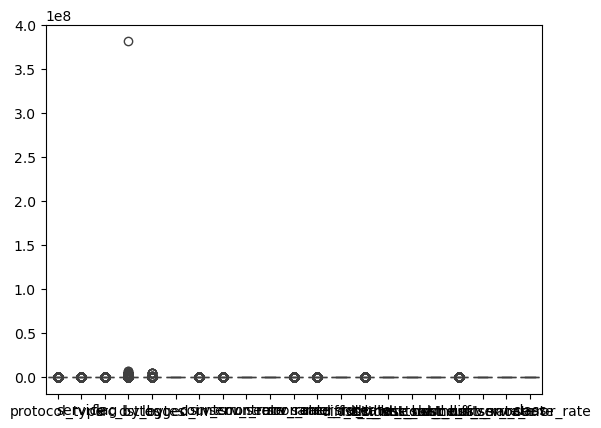

In [54]:
import seaborn as sns
sns.boxplot(df)

In [55]:
from sklearn.model_selection import train_test_split
X = df.drop('class', axis=1)
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
# use random forest classifier to train the model
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [58]:
y_pred = rf.predict(X_test)

In [59]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2674
           1       1.00      1.00      1.00      2365

    accuracy                           1.00      5039
   macro avg       1.00      1.00      1.00      5039
weighted avg       1.00      1.00      1.00      5039

[[2670    4]
 [   8 2357]]
0.9976185751141099


In [61]:
# convert the model to pickle file
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(rf, f)
# label encoder to pickle file
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)